In [ ]:
!pip install yfinance ta tensorflow

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=ab498521d1940a521587a6d09a1f9774fda8e858577e9dc799e922c70e48b2d1
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import ta

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [ ]:
def run_prediction(symbol, name):

    print(f"\n🔥 Running AI Prediction for {name}")

    df = yf.download(symbol,
                     start="2010-01-01",
                     end="2024-01-01")

    df.columns = df.columns.get_level_values(0)
    df = df[['Close','Volume']]


    df['EMA20'] = ta.trend.ema_indicator(df['Close'], window=20)
    df['RSI'] = ta.momentum.rsi(df['Close'], window=14)

    macd = ta.trend.MACD(df['Close'])
    df['MACD'] = macd.macd()

    df.dropna(inplace=True)

    features = ['Close','Volume','EMA20','RSI','MACD']

    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df[features])


    sequence_len = 60
    x=[]
    y=[]

    for i in range(sequence_len, len(scaled_data)):
        x.append(scaled_data[i-sequence_len:i])
        y.append(scaled_data[i,0])

    x=np.array(x)
    y=np.array(y)

    split=int(len(x)*0.8)

    x_train=x[:split]
    x_test=x[split:]

    y_train=y[:split]
    y_test=y[split:]


    model=Sequential()

    model.add(LSTM(32, return_sequences=True,
                   input_shape=(x_train.shape[1],
                                x_train.shape[2])))
    model.add(Dropout(0.2))

    model.add(LSTM(32))
    model.add(Dropout(0.2))

    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mse')

    model.fit(x_train,y_train,
              epochs=5,
              batch_size=32,
              verbose=0)

    pred=model.predict(x_test)


    dummy=np.zeros((len(pred),len(features)))
    dummy[:,0]=pred[:,0]
    pred_prices=scaler.inverse_transform(dummy)[:,0]

    dummy2=np.zeros((len(y_test),len(features)))
    dummy2[:,0]=y_test
    real_prices=scaler.inverse_transform(dummy2)[:,0]


    rmse=np.sqrt(mean_squared_error(real_prices,pred_prices))
    r2=r2_score(real_prices,pred_prices)

    print(f"{name} RMSE:", rmse)
    print(f"{name} Accuracy (%):", round(r2*100,2))


    plt.figure(figsize=(12,5))
    plt.plot(real_prices,label="Real Price")
    plt.plot(pred_prices,label="AI Prediction")
    plt.title(f"{name} AI Prediction")
    plt.legend()
    plt.show()


🔥 Running AI Prediction for GOLD


/tmp/ipykernel_5378/1126843763.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol,
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
GOLD RMSE: 30.327130425124743
GOLD Accuracy (%): 90.4


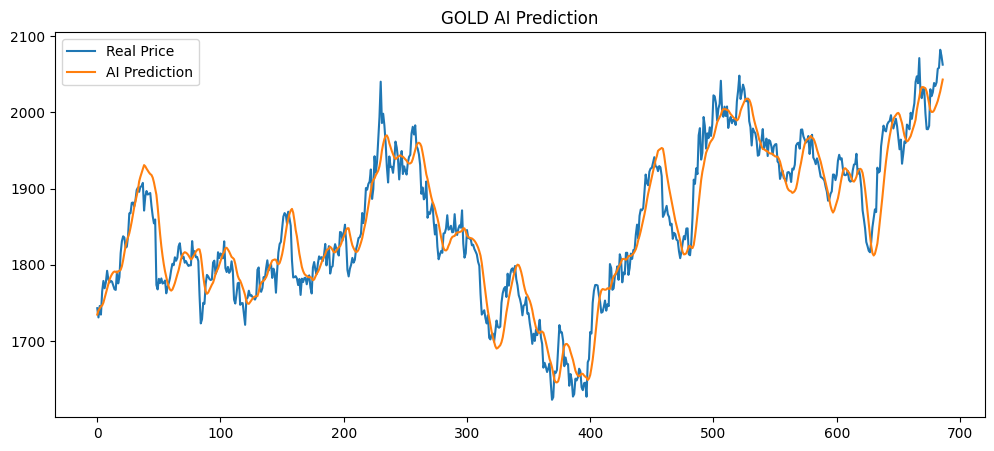

In [ ]:
run_prediction("GC=F", "GOLD")


🔥 Running AI Prediction for SILVER


/tmp/ipykernel_5378/1126843763.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol,
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
SILVER RMSE: 0.7988303104433737
SILVER Accuracy (%): 86.78


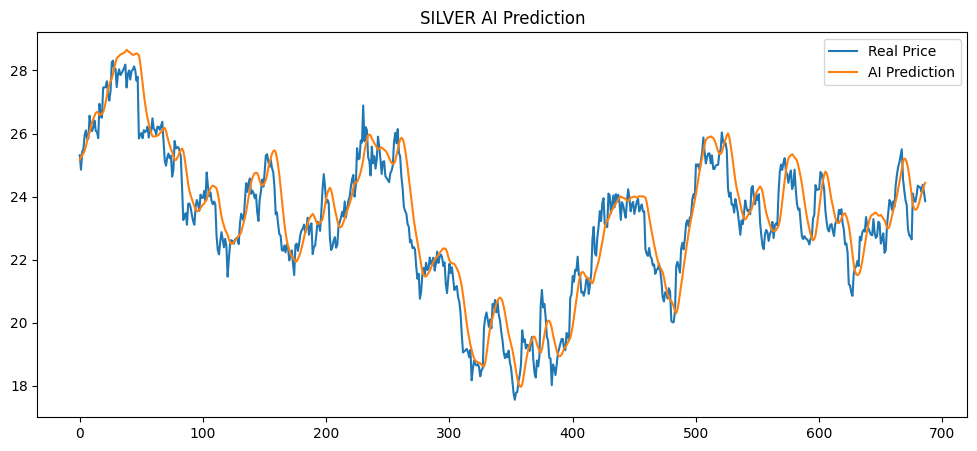

In [ ]:
run_prediction("SI=F", "SILVER")